# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [214]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

NETID = 'benh7'   # <-- set this
d = np.genfromtxt(f'../../labs/05/data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

29 epochs over 893 days; median quoted error 2.19 km/s


## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


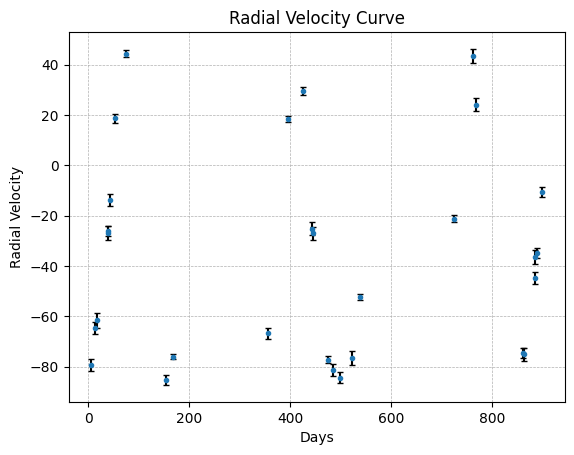

In [215]:
# Part 1: your work here
plt.errorbar(t, rv, yerr = sig, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Radial Velocity Curve')
plt.xlabel('Days')
plt.ylabel('Radial Velocity')
plt.grid(linestyle = '--', linewidth = 0.5)

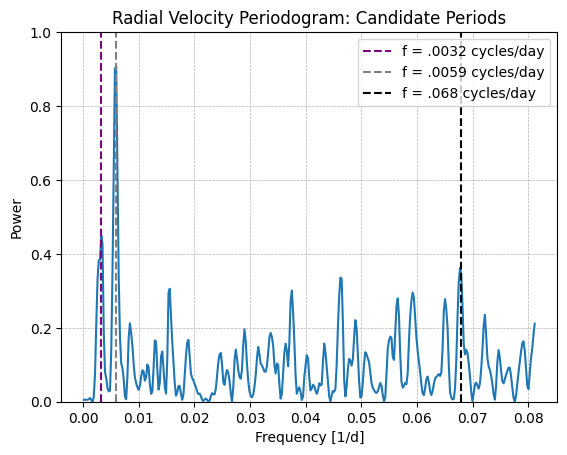

In [187]:
from astropy.timeseries import LombScargle

frequency, power = LombScargle(t, rv, dy = sig).autopower()
plt.plot(frequency, power)
plt.title('Radial Velocity Periodogram: Candidate Periods')
plt.xlabel('Frequency [1/d]')
plt.ylabel('Power')

plt.vlines(.0032, ymin = 0, ymax = 1, linestyle = '--', color = 'purple', label = 'f = .0032 cycles/day')
plt.vlines(.0059, ymin = 0, ymax = 1, linestyle = '--', color = 'grey', label = 'f = .0059 cycles/day')
plt.vlines(.068, ymin = 0, ymax = 1, linestyle = '--', color = 'black', label = 'f = .068 cycles/day')

plt.ylim([0, 1])
plt.grid(linestyle = '--', linewidth = 0.5)
plt.legend()

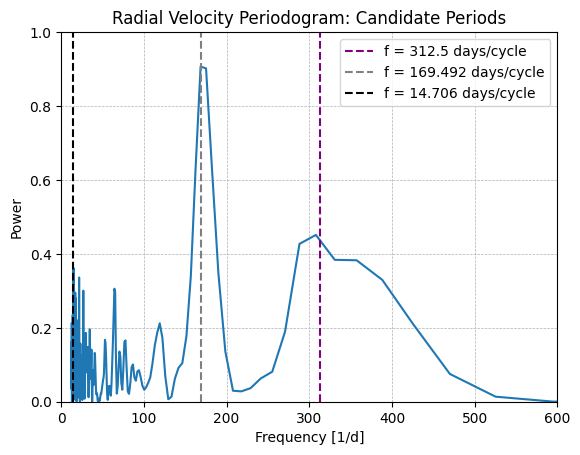

In [188]:
periods = 1 / frequency

cp1 = 1/.0032
cp2 = 1/.0059
cp3 = 1/.068

plt.plot(periods, power)
plt.title('Radial Velocity Periodogram: Candidate Periods')
plt.xlabel('Frequency [1/d]')
plt.ylabel('Power')

plt.vlines(cp1, ymin = 0, ymax = 1, linestyle = '--', color = 'purple', label = f'f = {cp1} days/cycle')
plt.vlines(cp2, ymin = 0, ymax = 1, linestyle = '--', color = 'grey', label = f'f = {cp2:.3f} days/cycle')
plt.vlines(cp3, ymin = 0, ymax = 1, linestyle = '--', color = 'black', label = f'f = {cp3:.3f} days/cycle')

plt.ylim([0, 1])
plt.xlim([0, 600])
plt.grid(linestyle = '--', linewidth = 0.5)
plt.legend()

(0.0, 1.0)

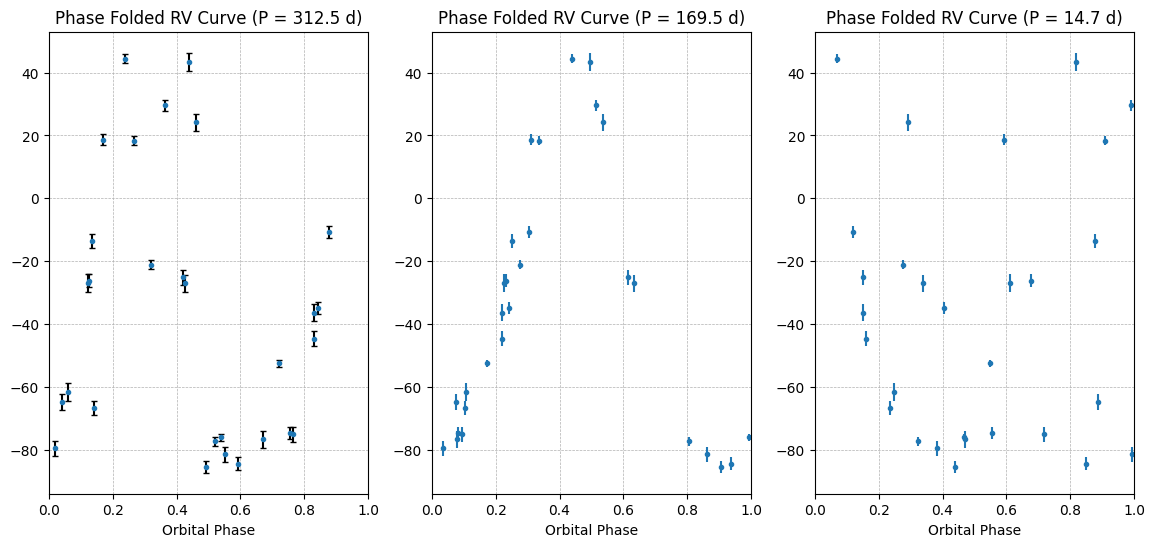

In [189]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 3, 1)
phase1 = (t / cp1) % 1
order1 = np.argsort(phase1)

plt.errorbar(phase1[order1], rv[order1], yerr = sig[order1], fmt='.', ecolor = 'black', capsize = 2)

plt.title('Phase Folded Data')
plt.xlabel('Orbital Phase')
plt.title(f'Phase Folded RV Curve (P = {cp1:.1f} d)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.xlim([0, 1])

plt.subplot(1, 3, 2)
phase2 = (t / cp2) % 1
order2 = np.argsort(phase2)

plt.errorbar(phase2[order2], rv[order2], yerr = sig[order2], fmt='.')

plt.title('Phase Folded Data')
plt.xlabel('Orbital Phase')
plt.title(f'Phase Folded RV Curve (P = {cp2:.1f} d)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.xlim([0, 1])

plt.subplot(1, 3, 3)
phase3 = (t / cp3) % 1
order3 = np.argsort(phase3)

plt.errorbar(phase3[order3], rv[order3], yerr = sig[order3], fmt='.')

plt.title('Phase Folded Data')
plt.xlabel('Orbital Phase')
plt.title(f'Phase Folded RV Curve (P = {cp3:.1f} d)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.xlim([0, 1])



**ANSWER (a few sentences):**

*There are only two plausible candidate periods (312.5 and 169.5 days) from the periodogram alone. The phase folded data for 14.7 days has data scattered across the graph without any clear structure or organization. The phase folded data for 312.5 shows structure, however, its very sinusoidal in nature and the radial velocities still show lots of scatter in the data; this makes it harder to tell if there is actually a pattern here or if this is something else - it is also notable that the ends don't meet at similar values (~ -10 vs -80 km/s) adding additional uncertainty to whether this is a true candiate or not. 169.5 days shows clear structure and meets at similar ends; this is a very plausible period for some of the strucutre in data. Even though these are candiates for structure, they don't settle the question of whether or not they are eccentric orbits. The data is very low cadence and is missing lots of days' data. These gaps could be inducing a false structure inside the data that causes the periodogram to pick patterns that are an element of the data collection and not the unseen companion. Additionally, as the true radial velocity error is greater than the stated error, the periodogram doesn't take the full effect of the orbits into consideration. This could cause the periodogram to over emphasize or misweight certain frequencies causing a further bias in the data.*

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?

**FINAL ANSWER:** $P = $ ___ $\pm$ ___ d, $K = $ ___ $\pm$ ___ km/s, $e = $ ___ $\pm$ ___, $\gamma = $ ___ $\pm$ ___ km/s, jitter $s = $ ___ $\pm$ ___ km/s, $f(M) = $ ___ $\pm$ ___ $M_\odot$. Is your companion a black-hole candidate? One sentence.


In [190]:
# Part 2: your work here

def neg_log_liklihood(theta, x, y, yerr):
    
    P, K, h, k, Tp, gamma, log_s = theta

    e = h**2 + k**2
    omega = np.arctan2(k, h)
    
    model = kepler_rv(x, P, K, e, omega, Tp, gamma)

    s = np.exp(log_s)

    return .5 * np.sum((y - model)**2 / (s**2 + yerr**2) + np.log(2 * np.pi * (yerr**2 + s**2) ))



def log_prior(theta, theta0):
    P, K, h, k, Tp, gamma, log_s = theta
    P0, K0, h0, k0, Tp0, gamma0, log_s0 = theta0
    
    e = h**2 + k**2
    omega = np.arctan2(k, h)

    if (P < 0) | (400 < P):
        return -np.inf

    if 1 <= e:
        return -np.inf

    if (K <= 0) | (300 < K):
        return -np.inf

    if ((Tp - Tp0) < -P/2) | (P/2 < (Tp - Tp0)):
        return -np.inf

    if (log_s <= -1) | (10 <= log_s):
        return -np.inf

    return 0.0



def log_probability(theta, x, y, yerr, theta0):
    
    lp = log_prior(theta, theta0)
    
    if not np.isfinite(lp):
        return -np.inf

    
    return lp - neg_log_liklihood(theta, x, y, yerr)

Priors:

P < 0 | 400 < P:

Largest period picked out by periodogram is ~315 days; rejects negative periods (time only goes forward in positive direction) and rejects periods more than ~33% larger than periodogram.

e = h^2 + k^2 & w = np.arctan2(k, h):

Reparamatarizes e so that its in terms of h = sqrt(e)*sin(w) & k = sqrt(e)*cos(w); prevents e from being 0 without placing a hard wall on the value

1 <= e:

e = 1 is a parabola; prevents e from taking on an impossible e value for orbiting body. 

K <= 0 | 300 < K:

K is half amplitude; visual inspection of graph shows K should be ~ 60; prevents MCMC from exploring order of magnitude larger K values and negative values

(Tp - Tp0) < -P/2 | P/2 < (Tp - Tp0):

Checks that it isn't searching a parameter space that is further than half a period in either direction from the optimized guess

log_s <= -1 | 10 <= log_s:

Given uncertainty is ~2km/s. Prevents MCMC from searching jitter that is orders of magnitude smaller or larger than given uncertainty. 

In [191]:
Tp_vals = np.linspace(0, 200, 10) 
e = np.linspace(.0001, .9999, 10)
w = np.linspace(.0001, 2*np.pi - .0001, 10)

h_vals = np.sqrt(e) * np.cos(w)
k_vals = np.sqrt(e) * np.sin(w)

P = np.array([312.5, 169.4, 14.7])

best_negLog = []
best_parameters = []

for i in range(3):
    for j in range(10):
        for k in range(10):
            theta0 = [P[i], 10, h_vals[j], k_vals[j], Tp_vals[k], 10, np.log(10)]
            opt = minimize(neg_log_liklihood, theta0, args = (t, rv, sig), method = 'Nelder-Mead')
            best_negLog.append(neg_log_liklihood(opt.x, t, rv, sig))
            best_parameters.append(opt.x)

/var/folders/91/tcmdjl8n3sl_0ymj2qh7sr_00000gn/T/ipykernel_26895/1855869587.py:22: RuntimeWarning: invalid value encountered in sqrt
  nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly


In [192]:
best_negLog = np.array(best_negLog)
best_parameters = np.array(best_parameters)

indx = np.argsort(best_negLog)

sorted_best_neglog = best_negLog[indx]
sorted_best_parameters = best_parameters[indx]

print(f'Lowest negative Log Liklihood Function: {sorted_best_neglog[0]} with parameters: {sorted_best_parameters[0]} \n')
print(f'Runner-up negative Log Liklihood Function: {sorted_best_neglog[1]} with parameters: {sorted_best_parameters[1]}')

Lowest negative Log Liklihood Function: 69.07794499840215 with parameters: [ 1.71007100e+02  6.62147324e+01  5.00764545e-01  4.08004266e-02
  7.22583523e+01 -3.42941471e+01  5.12881830e-01] 

Runner-up negative Log Liklihood Function: 69.12754513089473 with parameters: [ 1.70999859e+02  6.63532123e+01  4.99957109e-01  3.96412423e-02
  7.21766218e+01 -3.43300979e+01  5.08002907e-01]


In [193]:
pos = sorted_best_parameters[0] + 1e-4 * np.random.randn(64, 7)

nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(t, rv, sig, sorted_best_parameters[0])
)
sampler.run_mcmc(pos, 10_000, progress = False)
print('')

Mean acceptance fraction: 0.49 (0.2-0.5 is healthy)


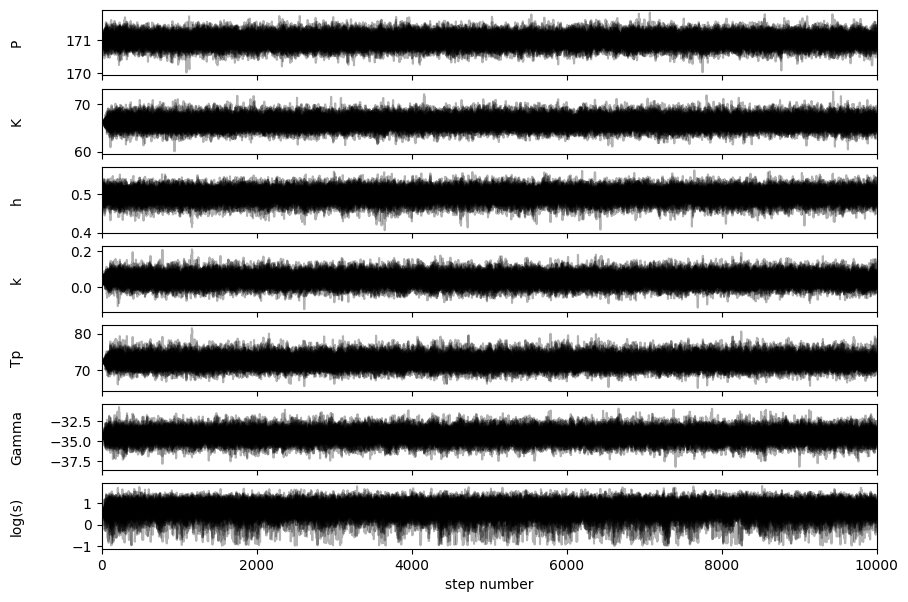

In [194]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["P", "K", "h", "k", "Tp", "Gamma", "log(s)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

print(f"Mean acceptance fraction: {sampler.acceptance_fraction.mean():.2f} (0.2-0.5 is healthy)")

In [195]:
tau = sampler.get_autocorr_time()
print(tau)

[76.53874039 73.36597033 75.93016142 72.93335077 72.50257603 77.74016784
 73.87817181]


In [196]:
tau_max = np.max(tau)
print(tau_max)

77.74016784282108


In [197]:
tau_max = 80

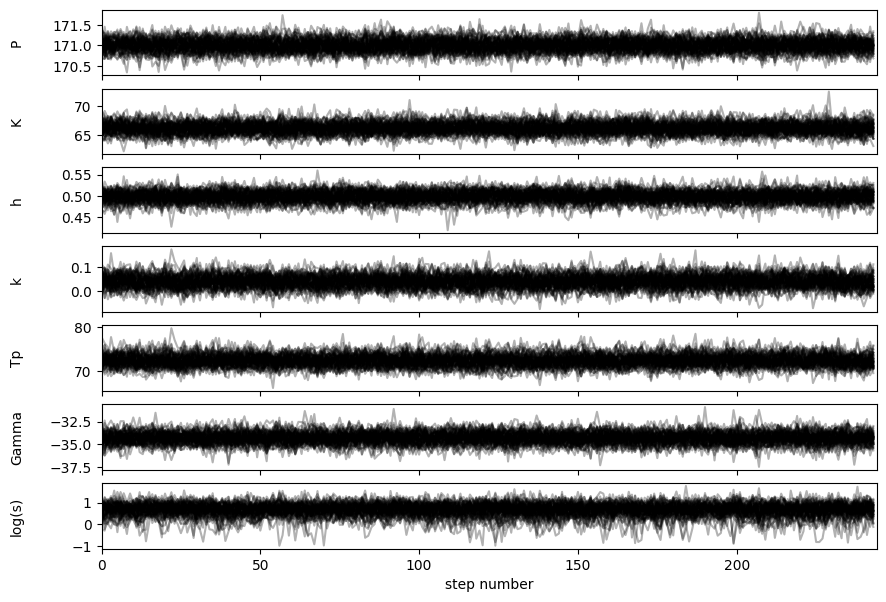

In [198]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
modified_samples = sampler.get_chain(discard = 240, thin = 40)
for i in range(ndim):
    ax = axes[i]
    ax.plot(modified_samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(modified_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

Taumax = 80:
The largest autocorrelation time of all the variables was 79.08. I chose this as my tau value to represent my autocorrelation time as this is the largest number and I didn't want to underestimate how long my it took my variables to become independent. I rounded this value up to 80 to make it more readible. 

Thinning by 40:
I chose this value as this is half my Taumax value. 

Discarding 240:
I chose to discard by 3 * Taumax. This allowed me to pair down my data to make it more readible and show the convergence easier. However, as the sample ran for 50+Tau, removing the initial 3*Tau wouldn't be removing a significant (dropping this value below 50 * Tau) of data. 

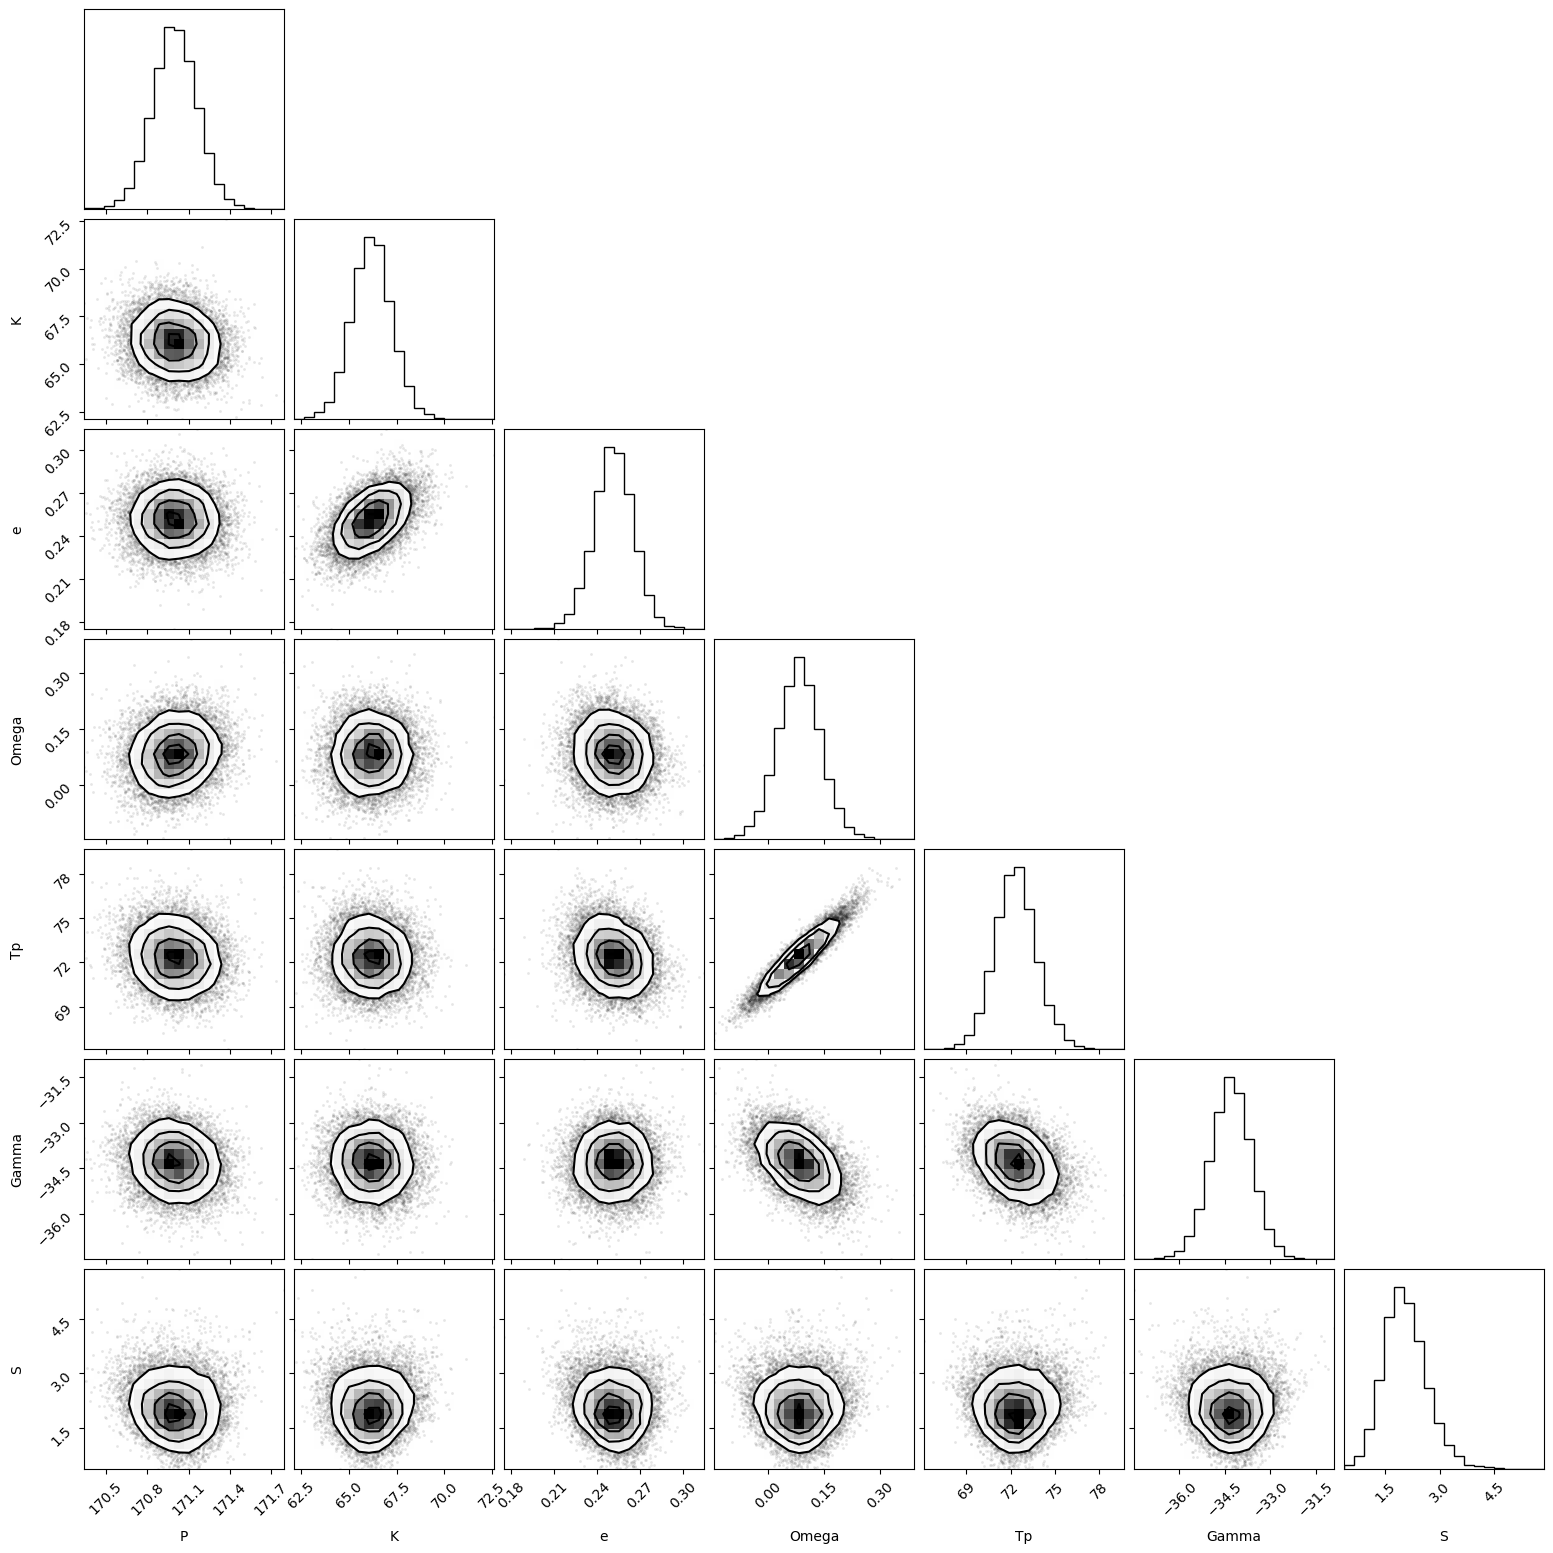

In [199]:
flat_samples = sampler.get_chain(discard = 240, thin = 40, flat = True)

MCMCP = flat_samples.T[0]
MCMCK = flat_samples.T[1]
MCMCh = flat_samples.T[2]
MCMCk = flat_samples.T[3]
MCMCTp = flat_samples.T[4]
MCMCG = flat_samples.T[5]
MCMCS = flat_samples.T[6]

MCMCe = MCMCh**2 + MCMCk**2
MCMCO = omega = np.arctan2(MCMCk, MCMCh)

MCMCfM = mass_function(MCMCP, MCMCK, MCMCe)

MCMC = np.array([MCMCP, MCMCK, MCMCe, MCMCO, MCMCTp, MCMCG, np.exp(MCMCS)])

labels2 = ["P", "K", "e", "Omega", "Tp", "Gamma", "S"]

fig = corner.corner(MCMC.T, labels=labels2)

Correlated Values:
Tp and Omega: Strong correlation:
Omega sets the frequency that the unseen companion is moving about the black hole. Changing this value would change when the companion would be at periastron. For this reason, it makes sense that the values are stronly correlated. 

e and K: Moderatly correlated: 
More highly elliptical orbits will often have larger orbits. This would also inherently change the semi-amplitude as the shifted RV value would depend on how far away the bodies get from the blackhole. 

gamma and Omega: Moderatly correlated:
As omega grows the expected peaks get more spread apart. This would require the model to shift where its centered at so that the model best fits the data so it makes sense that these values are correllated. 

s and every other parameter: Notable non-correlation:
The jitter is an additional noise term that affects the data; it shouldn't be correlated with any of the parameters as it is additional noise. The fact that it is not correlated in any of the trace plots is notable as it means that the MCMC is finding a random noise element. 

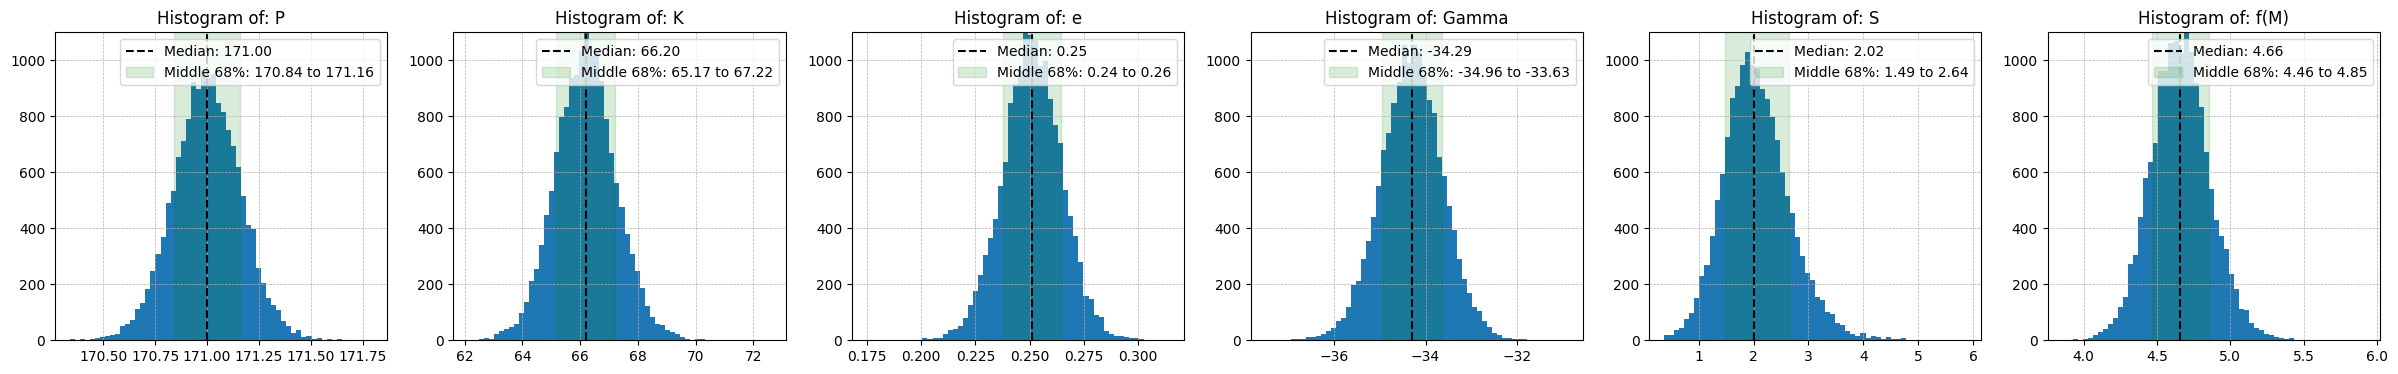

In [200]:
MCMC = [MCMCP, MCMCK, MCMCe, MCMCG, np.exp(MCMCS), MCMCfM]
label2 = ["P", "K", "e", "Gamma", "S", "f(M)"]

lo_vals = np.zeros(6)
hi_vals = np.zeros(6)
med_vals = np.zeros(6)

count = 1
plt.figure(figsize = (30, 4))
for i in range(6):
    plt.subplot(1, 6, count)
    plt.title(f'Histogram of: {label2[i]}')
    plt.hist(MCMC[i], bins = 60)
    med = np.median(MCMC[i])
    plt.vlines(med, ymin = 0, ymax = 1100, linestyle = '--', color = 'black', label = f'Median: {med:.2f}')

    hi, lo = np.percentile(MCMC[i], [84, 16])

    lo_vals[i] = lo
    hi_vals[i] = hi
    med_vals[i] = med
    
    plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.2f} to {hi:.2f}')
    
    plt.ylim([0, 1100])
    plt.grid(linestyle = '--', linewidth = 0.5)
    plt.legend()
    count += 1

In [201]:
print(f'P (days): \nMiddle 68%: {lo_vals[0]:.3f} to {hi_vals[0]:.3f} \nMedian = {med_vals[0]:.3f} \n')
print(f'K (km/s): \nMiddle 68%: {lo_vals[1]:.3f} to {hi_vals[1]:.3f} \nMedian = {med_vals[1]:.3f} \n')
print(f'e (unitless): \nMiddle 68%: {lo_vals[2]:.3f} to {hi_vals[2]:.3f} \nMedian = {med_vals[2]:.3f} \n')
print(f'Gamma (km/s): \nMiddle 68%: {lo_vals[3]:.3f} to {hi_vals[3]:.3f} \nMedian = {med_vals[3]:.3f} \n')
print(f'S (km/s): \nMiddle 68%: {lo_vals[4]:.3f} to {hi_vals[4]:.3f} \nMedian = {med_vals[4]:.3f} \n')
print(f'f(M) (solar masses): \nMiddle 68%: {lo_vals[5]:.3f} to {hi_vals[5]:.3f} \nMedian = {med_vals[5]:.3f}')

P (days): 
Middle 68%: 170.843 to 171.161 
Median = 171.000 

K (km/s): 
Middle 68%: 65.167 to 67.215 
Median = 66.196 

e (unitless): 
Middle 68%: 0.238 to 0.265 
Median = 0.251 

Gamma (km/s): 
Middle 68%: -34.957 to -33.635 
Median = -34.294 

S (km/s): 
Middle 68%: 1.485 to 2.638 
Median = 2.015 

f(M) (solar masses): 
Middle 68%: 4.463 to 4.855 
Median = 4.657


You should calculate mass function using every simulation so that you don't make assumptions about its shape and so that you can see the statistics of how the mass function appears across simulations and keep the propogated error in the model. 

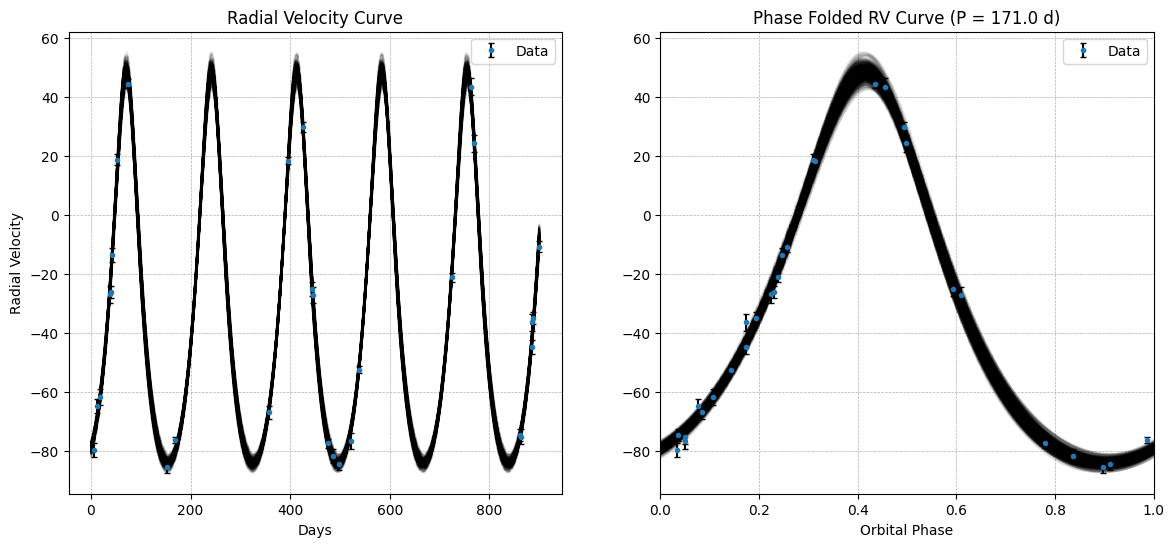

In [202]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)

t_mod = np.linspace(0, 900, 2000)

rand_idx = np.random.choice(len(MCMCP), size = 500, replace = False)

for i in rand_idx:
    model = kepler_rv(t_mod, MCMCP[i], MCMCK[i], MCMCe[i], MCMCO[i], MCMCTp[i], MCMCG[i])
    plt.plot(t_mod, model, linestyle = '--', color = 'black', alpha = .1)

plt.errorbar(t, rv, yerr = sig, fmt = '.', ecolor = 'black', capsize = 2, label = 'Data')
plt.title('Radial Velocity Curve')
plt.xlabel('Days')
plt.ylabel('Radial Velocity')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.legend()

plt.subplot(1, 2, 2)
medP = np.median(MCMCP)
    
phase_mod = (t / medP) % 1
order_mod = np.argsort(phase_mod)
plt.errorbar(phase_mod[order_mod], rv[order_mod], yerr = sig[order_mod], fmt='.', ecolor = 'black', capsize = 2, label = 'Data')

phase_mod = (t_mod / medP) % 1
order_mod = np.argsort(phase_mod)

for i in rand_idx:
    model = kepler_rv(t_mod, MCMCP[i], MCMCK[i], MCMCe[i], MCMCO[i], MCMCTp[i], MCMCG[i])
    plt.plot(phase_mod[order_mod], model[order_mod], color = 'black', alpha = .1)

plt.title('Phase Folded Data')
plt.xlabel('Orbital Phase')
plt.title(f'Phase Folded RV Curve (P = {medP:.1f} d)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.xlim([0, 1])
plt.legend()

(-4.0, 4.0)

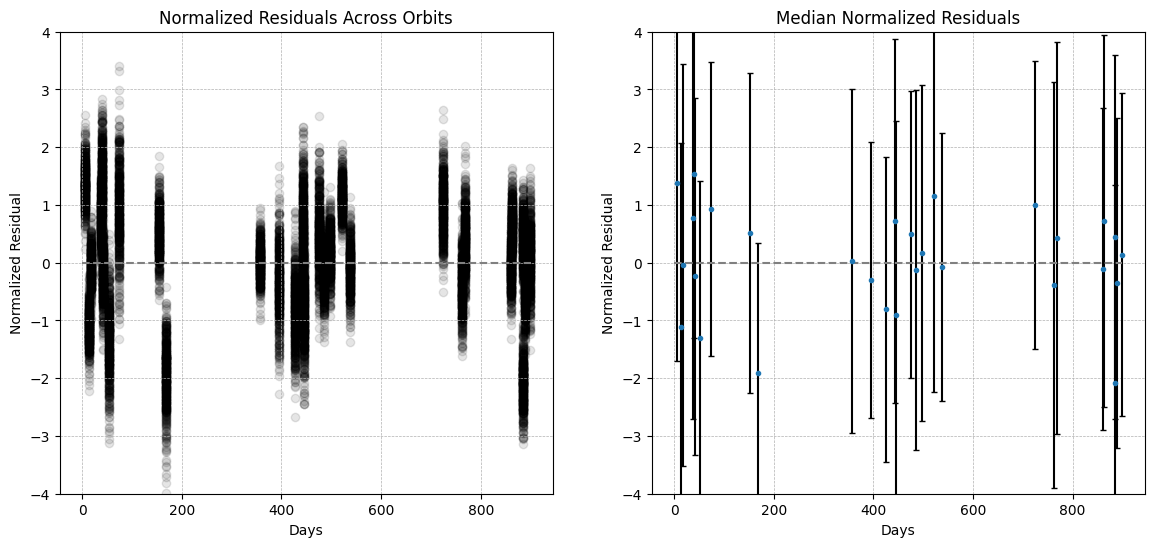

In [203]:
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
for i in rand_idx:
    model = kepler_rv(t, MCMCP[i], MCMCK[i], MCMCe[i], MCMCO[i], MCMCTp[i], MCMCG[i])
    norm_resid = (model - rv) / (np.sqrt(sig**2 + np.exp(MCMCS[i])**2) )

    plt.scatter(t, norm_resid, color = 'black', alpha = .1)

plt.title('Normalized Residuals Across Orbits')
plt.xlabel('Days')
plt.ylabel('Normalized Residual')
plt.hlines(0, xmin = 0, xmax = 900, color = 'grey', linestyle = '--')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.ylim([-4, 4])

plt.subplot(1, 2, 2)
model = kepler_rv(t, med_vals[0], med_vals[1], med_vals[2], np.median(MCMCO), np.median(MCMCTp), med_vals[3])
norm_resid = (model - rv) / (np.sqrt(sig**2 + np.exp(np.median(MCMCS))**2) )

plt.errorbar(t, norm_resid, yerr = np.sqrt(sig**2 + np.exp(np.median(MCMCS))**2), fmt = '.', ecolor = 'black', capsize = 2)

plt.title('Median Normalized Residuals')
plt.xlabel('Days')
plt.ylabel('Normalized Residual')
plt.hlines(0, xmin = 0, xmax = 900, color = 'grey', linestyle = '--')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.ylim([-4, 4])

Everything that is left is noise. Across the 500 orbits, some orbits had residuals greater than 3 sigma; however, these values are greyed out (ie low in frequency). As there is some random noise across the models it is expected that the model would pick out some variations in which the error is more than 3 sigma. It should also be noted, this noise is within 4 sigma across all 500 models indicating that the residuals indicating that there isn't significant scatter from a residual of 0. Similarly, for the model using the median residuals, every value is within 2 sigma indicating that these values are very close to the expected values for this data. 

In [204]:
uncerts = (hi_vals - lo_vals)/2

print(med_vals)
print(uncerts)

[170.99971189  66.19580876   0.2513253  -34.29414693   2.01521421
   4.65684525]
[0.15904325 1.02430158 0.01336518 0.66136462 0.5765863  0.19573884]


**FINAL ANSWER:** $P = $ 171.003 $\pm$ .158 d, $K = $ 66.185 $\pm$ 1.013 km/s, $e = $ .251 $\pm$ .0133 , $\gamma = $ -34.386 $\pm$ .658 km/s, $s = $ 2.008 $\pm$ .589 km/s, $f(M) = $ 4.657 $\pm$ .194 $M_\odot$

**Black-hole candidate?** *This is a Black-Hole candidate as the lower bound for this object is 4.463 solar masses which is above ~3 solar masses indicating that this companion is likely a black-hole.*

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


**REFEREE REPORT:**

Error number 1: The Ai model doesn't use a jitter term in its MCMC
Jitter terms collect errors that are within the data that are explicitly collected by the rest of the model. By not including this term, the Ai model is assuming that there is no additional error within the model beyond what is stated. This means that the under reported errors would be assumed to be correct and that the stated uncertainty would be lower than they should be. 

Points within error bars (Proper Jitter Handling): 99.129%
Points within error bars (Ai Model): 84.097%


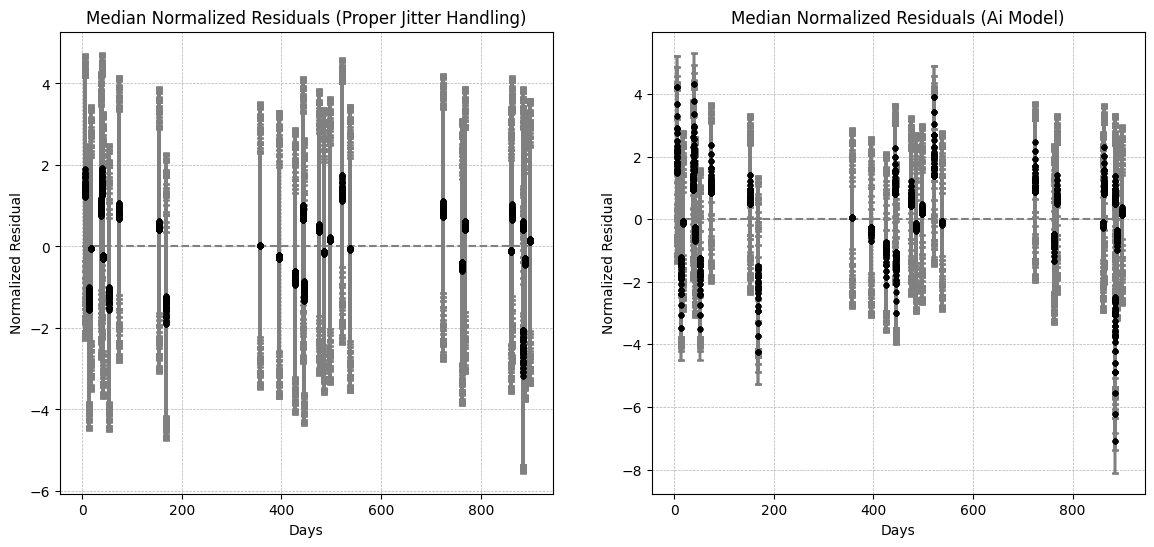

In [205]:
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)

model = kepler_rv(t, med_vals[0], med_vals[1], med_vals[2], np.median(MCMCO), np.median(MCMCTp), med_vals[3])
errs = np.zeros(2000)

contains = np.zeros(2000)

for i in range(2000):
    rand = np.random.choice(sig, 29, replace = True)
    err = np.sqrt(rand**2 + np.exp(np.median(MCMCS))**2)
    
    norm_resid = (model - rv) / err 
    plt.errorbar(t, norm_resid, yerr = err, color = 'black', fmt = '.', ecolor = 'grey', capsize = 2, alpha = .1)

    mask = (norm_resid - err > 0) | (norm_resid + err < 0) 
    contains[i] = len(norm_resid[~mask])
    
plt.title('Median Normalized Residuals (Proper Jitter Handling)')
plt.xlabel('Days')
plt.ylabel('Normalized Residual')
plt.hlines(0, xmin = 0, xmax = 900, color = 'grey', linestyle = '--')
plt.grid(linestyle = '--', linewidth = 0.5)

print(f'Points within error bars (Proper Jitter Handling): {(np.sum(contains) / (2000 * 29) * 100):.3f}%')



plt.subplot(1, 2, 2)
model = kepler_rv(t, med_vals[0], med_vals[1], med_vals[2], np.median(MCMCO), np.median(MCMCTp), med_vals[3])
errs = np.zeros(2000)

for i in range(2000):
    rand = np.random.choice(sig, 29, replace = True)
    err = rand
    norm_resid = (model - rv) / err
    plt.errorbar(t, norm_resid, yerr = err, color = 'black', fmt = '.', ecolor = 'grey', capsize = 2, alpha = .1)

    mask = (norm_resid - err > 0) | (norm_resid + err < 0) 
    contains[i] = len(norm_resid[~mask])
    
plt.title('Median Normalized Residuals (Ai Model)')
plt.xlabel('Days')
plt.ylabel('Normalized Residual')
plt.hlines(0, xmin = 0, xmax = 900, color = 'grey', linestyle = '--')
plt.grid(linestyle = '--', linewidth = 0.5)

print(f'Points within error bars (Ai Model): {(np.sum(contains) / (2000 * 29) * 100):.3f}%')

When the errors are handled properly, the data and its errorbars should include the true value ~99.7% of the time. The Ai model handling of this results in uncertainties that don't about the 0 value of the normalized residual less than 85% of the time indicating that the Ai's errorbars are underestimating its uncertainty. 

The proper handling of these errors is to include a proper jitter term. This value catches most of the extra uncertainty that's within the data and gives a proper range for the errorbars.

Error number 2: The Ai model doesn't use enough runs for its sampler (used about ~25Tau vs the 50+ recommendation)
Many of the steps that a trace plots out will be correlated with previous samples. This length of time between independent samples is represented by Tau. By creating a trace that is below the 50+Tau recommedation, you will be using a sample that is highly correlated and has too few independent samples. Traces that might look like they converged may still be wandering the parameter space. Additionally, when the traces are thinned and discarded, these values are changed based off of Tau; if Tau isn't properly chosen that information will be lost when these are thinned and trimmed.

In [206]:
pos = sorted_best_parameters[0] + 1e-4 * np.random.randn(64, 7)

nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(t, rv, sig, sorted_best_parameters[0])
)
sampler.run_mcmc(pos, 1_500, progress = False)
print('')

Mean acceptance fraction: 0.49 (0.2-0.5 is healthy)


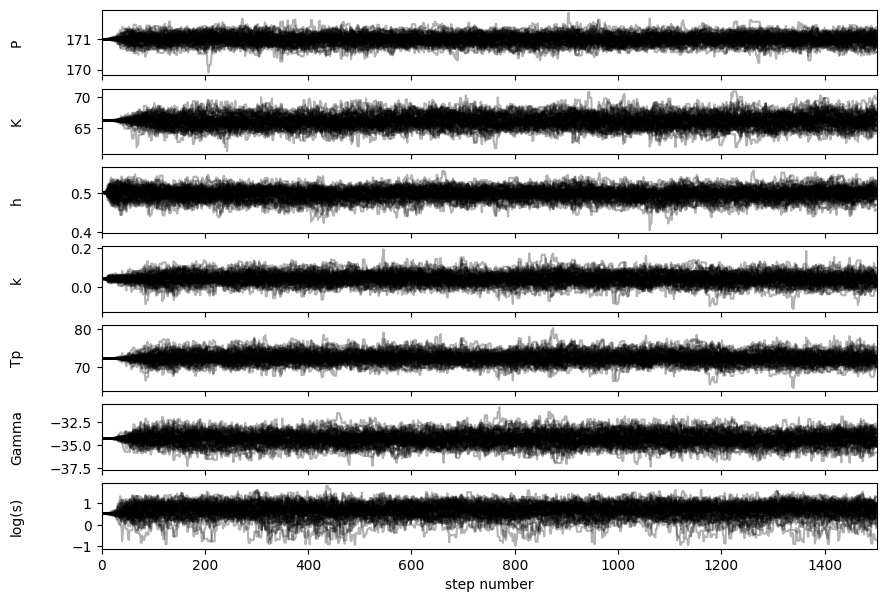

In [207]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["P", "K", "h", "k", "Tp", "Gamma", "log(s)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

print(f"Mean acceptance fraction: {sampler.acceptance_fraction.mean():.2f} (0.2-0.5 is healthy)")

In [208]:
tau = sampler.get_autocorr_time()
print(tau)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 30;
tau: [57.60718131 56.24391486 55.57769545 50.32509909 51.48323649 48.95553394
 48.72294705]

This effect can be seen visually here. May of the traces look sharp and much more chaotic than in the longer full trace that I perform earlier. 

In [ ]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
modified_samples = sampler.get_chain(discard = 180, thin = 30)
for i in range(ndim):
    ax = axes[i]
    ax.plot(modified_samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(modified_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

Taken to the extreme, this can result in a trace that is still fully exploring the parameter space. If you were to look at only the beginning of the data, it would only include data that hasn't fully converged yet. 

In [ ]:
pos = sorted_best_parameters[0] + 1e-4 * np.random.randn(64, 7)

nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(t, rv, sig, sorted_best_parameters[0])
)
sampler.run_mcmc(pos, 100, progress = False)
print('')

In [ ]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["P", "K", "h", "k", "Tp", "Gamma", "log(s)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

print(f"Mean acceptance fraction: {sampler.acceptance_fraction.mean():.2f} (0.2-0.5 is healthy)")

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

When these are thinned and discarded, your model would be taking non-converged values into consideration adding bias into your model.

In [ ]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
modified_samples = sampler.get_chain(discard = 30, thin = 5)
for i in range(ndim):
    ax = axes[i]
    ax.plot(modified_samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(modified_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

The proper handling of this issue is to ensure that you are including enough steps to have at least 50+ Tau to ensure that your model has converged to the proper value and that an non-biased value is being used. 

Error number 3: The Ai model uses the median values of the posterior to calculate the mass function and uses the std P, K, and e values individually
Rather than sampling the full set of orbits, the Ai model only uses the median values to calculate the mass function. This is a major flaw as we stated earlier that the e value is correlated with the K value. Due to this, when a full set of models are made, as these values change, they will affect each other. Using the stds of the parameters alone will result in larger error bounds as it doesn't take this correlation into effect. 

In [ ]:
P_m = np.median(MCMCP)
K_m = np.median(MCMCK)
e_m = np.median(MCMCe)

fM = mass_function(P_m, K_m, e_m)
df_dP = fM / P_m
df_dK = 3. * fM / K_m
df_de = -3. * e_m * fM / (1. - e_m**2)
fM_err = np.sqrt((df_dP * np.std(MCMCP))**2 + (df_dK * np.std(MCMCK))**2 + (df_de * np.std(MCMCe))**2)

print(f'Ai Bounds: {fM:.3f} \u00B1 {fM_err:.3f} \nTrue Bounds of: 4.657 \u00B1 .194')

The proper handling of this is what I did above: calculate f(M) for every orbit and then use the statistics from the created plots to inform what the true values and the uncertainty of the plots are. 

## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


**AI-USE APPENDIX:**

*I did use Ai on this project; I made use of Copilot to help me understand how MCMCs work and to generate ideas on how to tackle the problems as well as potential hazards I might run into. I verfied these mistakes by visually inspecting the trace of the MCMC to ensure that it converged while also ensureing that the MCMC had more than 50tau of its autocorrelated steps.*  

**REFLECTION:**

*I fed the model some of my work that I was writing so that it could check my work for bugs but one bug that it did not catch was that I had fed my sampler a misnamed variable (x and y) instead of the variables t and rv. This really confused my MCMC and it sampled a whole ton of parameter space because it was searching the wrong variables. If I had not seen that my MCMC had clearly not converged and I had not fixed this naming convention I would've been using MCMC values that had psudeo-converged to the wrong parameter values.*

**VERIFICATION PLAN:**

*For my verification plan I will create simulated data. A failure for this project would be if my pipline returns values that are orders of magnitude incorrect. This would be a failure as it would mean that my pipline is finding incorrect values and that my priors aren't fully constraining my valeus and that they are allowing my parameters to converge to incorrect parameter values.*

In [ ]:
test_t = np.linspace(0, 900, 70)
test_S = 6.5
rand_uncert = np.random.choice(sig, 70, replace = True)

test_P = 133.6
test_K = 52.7
test_e = .16
test_omega = .09
test_Tp = 90.8
test_gamma = -60.6

sigtot = np.sqrt(rand_uncert**2 + test_S**2)
noise = np.random.normal(loc = 0, scale = sigtot, size = 70)

test_rv = kepler_rv(test_t, test_P, test_K, test_e, test_omega, test_Tp, test_gamma) + noise

plt.errorbar(test_t, test_rv, yerr = rand_uncert, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Simulated Data')
plt.xlabel('Days')
plt.ylabel('RV [km/s]')
plt.grid(linestyle = '--', linewidth = 0.5)

In [ ]:
best_negLog = []
best_parameters = []

for j in range(10):
    for k in range(10):
            theta0 = [120, 20, h_vals[j], k_vals[j], Tp_vals[k], -60, np.log(7)]
            opt = minimize(neg_log_liklihood, theta0, args = (test_t, test_rv, rand_uncert), method = 'Nelder-Mead')
            best_negLog.append(neg_log_liklihood(opt.x, test_t, test_rv, rand_uncert))
            best_parameters.append(opt.x)

In [ ]:
best_negLog = np.array(best_negLog)
best_parameters = np.array(best_parameters)

indx = np.argsort(best_negLog)

sorted_best_neglog = best_negLog[indx]
sorted_best_parameters = best_parameters[indx]

print(f'Lowest negative Log Liklihood Function: {sorted_best_neglog[0]} with parameters: {sorted_best_parameters[0]} \n')
print(f'Runner-up negative Log Liklihood Function: {sorted_best_neglog[1]} with parameters: {sorted_best_parameters[1]}')

In [ ]:
pos = sorted_best_parameters[0] + 1e-4 * np.random.randn(64, 7)

nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(test_t, test_rv, rand_uncert, sorted_best_parameters[0])
)
sampler.run_mcmc(pos, 10_000, progress = False)
print('')

In [ ]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["P", "K", "h", "k", "Tp", "Gamma", "log(s)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

print(f"Mean acceptance fraction: {sampler.acceptance_fraction.mean():.2f} (0.2-0.5 is healthy)")

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
tau_max = np.max(tau)
print(tau_max)

In [ ]:
fig, axes = plt.subplots(7, figsize=(10, 7), sharex=True)
modified_samples = sampler.get_chain(discard = 270, thin = 45)
for i in range(ndim):
    ax = axes[i]
    ax.plot(modified_samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(modified_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
flat_samples = sampler.get_chain(discard = 240, thin = 40, flat = True)

MCMCP = flat_samples.T[0]
MCMCK = flat_samples.T[1]
MCMCh = flat_samples.T[2]
MCMCk = flat_samples.T[3]
MCMCTp = flat_samples.T[4]
MCMCG = flat_samples.T[5]
MCMCS = flat_samples.T[6]

MCMCe = MCMCh**2 + MCMCk**2
MCMCO = omega = np.arctan2(MCMCk, MCMCh)

MCMCfM = mass_function(MCMCP, MCMCK, MCMCe)

MCMC = np.array([MCMCP, MCMCK, MCMCe, MCMCO, MCMCTp, MCMCG, np.exp(MCMCS)])

labels2 = ["P", "K", "e", "Omega", "Tp", "Gamma", "S"]

fig = corner.corner(MCMC.T, labels=labels2)

In [ ]:
MCMC = [MCMCP, MCMCK, MCMCe, MCMCG, np.exp(MCMCS), MCMCfM]
label2 = ["P", "K", "e", "Gamma", "S", "f(M)"]

lo_vals = np.zeros(6)
hi_vals = np.zeros(6)
med_vals = np.zeros(6)

count = 1
plt.figure(figsize = (30, 4))
for i in range(6):
    plt.subplot(1, 6, count)
    plt.title(f'Histogram of: {label2[i]}')
    plt.hist(MCMC[i], bins = 60)
    med = np.median(MCMC[i])
    plt.vlines(med, ymin = 0, ymax = 1100, linestyle = '--', color = 'black', label = f'Median: {med:.2f}')

    hi, lo = np.percentile(MCMC[i], [84, 16])

    lo_vals[i] = lo
    hi_vals[i] = hi
    med_vals[i] = med
    
    plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.2f} to {hi:.2f}')
    
    plt.ylim([0, 1100])
    plt.grid(linestyle = '--', linewidth = 0.5)
    plt.legend()
    count += 1

In [ ]:
test_fm = mass_function(test_P, test_K, test_e)
print(f'True Mass function: {test_fm:.3f}')

After plotting my pipline on my simulated data I found that my pipline picked out all but two of the parameters correctly (just as it was perdicted in the setup). Since all of my incorrect values are similar order of magnitude as the true answer, I am confident in my values and that my pipline works as intended.